In [31]:
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 1e-4
k_folds=5

CSV_PATH = "/kaggle/input/updated-text-file/tokenized_updated (1).csv"
IMAGE_DIR = "/kaggle/input/multimodal-ifnd-3/resized_images (2)/resized_images"

In [32]:
import os
import zipfile
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
from transformers import DataCollatorWithPadding, DistilBertTokenizer
from transformers.models.distilbert import DistilBertModel, DistilBertTokenizer
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
from torch.optim.lr_scheduler import OneCycleLR
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, f1_score,
    precision_score, recall_score,
    precision_recall_curve, auc
)


In [33]:
!pip install focal_loss_torch

In [34]:
class NewsDataset(Dataset):
    def __init__(self, csv_path, image_dir, transform=None,
                 tokenizer_name='distilbert-base-uncased', max_length=64):
        self.csv_path = csv_path
        #self.image_zip_path = image_zip_path
        self.image_dir = image_dir
        self.transform = transform if transform else transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        self.tokenizer = DistilBertTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length

        

        # Extract images from zip if not already extracted
        #if not os.path.exists(self.image_dir):
         #   with zipfile.ZipFile(self.image_zip_path, 'r') as zip_ref:
          #      zip_ref.extractall(self.image_dir)

        # Load and clean the dataframe
        self.df = pd.read_csv(self.csv_path, usecols=['id', 'Statement', 'Web', 'Category', 'Date', 'Label'])
        # self.df.dropna(subset=['Statement'], inplace=True)

        # # Use new scikit-learn API
        # self.web_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        # self.cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

        # # Fit and transform metadata
        # self.web_encoded = self.web_encoder.fit_transform(self.df[['Web']])
        # self.cat_encoded = self.cat_encoder.fit_transform(self.df[['Category']])

        # # Assign unique column names to prevent index overlap
        # web_df = pd.DataFrame(self.web_encoded, columns=[f'web_{i}' for i in range(self.web_encoded.shape[1])])
        # cat_df = pd.DataFrame(self.cat_encoded, columns=[f'cat_{i}' for i in range(self.cat_encoded.shape[1])])

        # # Concatenate metadata features
        # meta_df = pd.concat([web_df, cat_df], axis=1)

        # # Convert to torch tensor
        # self.meta_features = torch.tensor(meta_df.values, dtype=torch.float32)

        # self.meta_dim = self.meta_features.shape[1]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Text encoding
        encoded = self.tokenizer(
        row['Statement'],
        truncation=True,
        max_length=self.max_length,
        return_attention_mask=True,
        return_tensors="pt"   # 🔥 Use tensors, let collator pad them later
        )


        # Image loading
        img_path = os.path.join(self.image_dir, f"img_{row['id']}.jpg")
        try:
            image = Image.open(img_path).convert('RGB')
            image = self.transform(image)
            image_mask = torch.tensor([1.0], dtype=torch.float32)  # Image is present
        except FileNotFoundError:
            image = torch.zeros(3, 224, 224)
            image_mask = torch.tensor([0.0], dtype=torch.float32)  # Image is missing
        #print("Image Mask Size in Dataset Class: ",image_mask.size())
            

        
            
            

        return {
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'image': image,
            'label': int(row['Label']),
            'id': int(row['id']),
            'image_mask': image_mask
            # 'meta': self.meta_features[idx]
        }
    

In [35]:
class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = DistilBertModel.from_pretrained("distilbert-base-uncased")
        for param in self.model.parameters():
            param.requires_grad = True
        self.dropout = nn.Dropout(0.3);

  #  def forward(self, input_ids, attention_mask):
       # print(">> DistilBERT received input_ids:", input_ids[0, :10])
   #     outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
       # print(">> CLS embedding sample:", outputs.last_hidden_state[:, 0, :5])
    #    return outputs.last_hidden_state[:, 0, :]
    def forward(self, input_ids, attention_mask):
     outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
     hidden_states = outputs.last_hidden_state  # (batch, seq_len, 768)

    # Mean pooling: sum(hidden * mask) / sum(mask)
     input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
     sum_embeddings = torch.sum(hidden_states * input_mask_expanded, 1)
     sum_mask = input_mask_expanded.sum(1).clamp(min=1e-9)
     return sum_embeddings / sum_mask


# [BATCH, SEQ_LEN, HIDDEN_DIM] => [BATCH, HIDDEN_DIM]

In [36]:
class ResNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        for param in self.feature_extractor.parameters():
            param.requires_grad = True


    def forward(self, x):
        x = self.feature_extractor(x).squeeze(-1).squeeze(-1)
        return x

In [37]:

class SimpleAttentionFusion(nn.Module):
    def __init__(self, text_dim=768, image_dim=2048, fusion_dim=512):
        super(SimpleAttentionFusion, self).__init__()

        # Project each modality to a common fusion dimension
        self.text_proj = nn.Linear(text_dim, fusion_dim)
        self.image_proj = nn.Linear(image_dim, fusion_dim)

        # Attention score generator
        self.attn = nn.Linear(fusion_dim, 1)

    def forward(self, text_feat, image_feat,image_mask=None, return_attention=False):
        # 1. Project to fusion_dim
        text_feat = self.text_proj(text_feat)       # (B, 512)
        image_feat = self.image_proj(image_feat)    # (B, 512)

        # 2. L2 Normalize projected features
        text_feat = F.normalize(text_feat, p=2, dim=1)   # (B, 512)
        image_feat = F.normalize(image_feat, p=2, dim=1) # (B, 512)

        # 3. Stack along modality dimension
        x = torch.stack([text_feat, image_feat], dim=1)  # (B, 2, 512)

        # 4. Compute attention logits
        attn_logits = self.attn(x).squeeze(-1)  # (B, 2)
        
        # 5. If image is not present, give full weightage to text
        # image_mask: (B,) → (B, 1)
        #print("Image Mask in Attention Fusion before Unsqueezing", image_mask.size())
        #image_mask = image_mask.unsqueeze(1)  # (B, 1)
        # Determine if image modality is present (non-zero entries)
        #print("Image Mask in Attention Fusion after Unsqueezing", image_mask.size())     

        # Stack to create modality mask
        modality_mask = torch.stack([torch.ones_like(image_mask),image_mask], dim=1)  # Final shape: [B, 2]  # Shape: [B, 2]
        #print("Modality mask", modality_mask.size())
        modality_mask= modality_mask.squeeze(1)
        #print("Modality mask", modality_mask.size())
        #print("Attention Logits", attn_logits.size())
        # Mask out attention logits where modality is not present
        attn_logits = attn_logits.masked_fill(modality_mask == 0, -1e9)  # Shape: [B, 2]

        # 5. Sigmoid + renormalization
        gates = torch.sigmoid(attn_logits)  # (B, 2) in (0, 1)
        attn_weights = gates / gates.sum(dim=1, keepdim=True)  # (B, 2), sum to 1

        # 6. Weighted sum to fuse
        fused = torch.sum(attn_weights.unsqueeze(-1) * x, dim=1)  # (B, 512)

        if return_attention:
            return fused, attn_logits, attn_weights
        return fused



In [38]:
class MLPReducer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.model(x)

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from itertools import product

class ANFISClassifier(nn.Module):
    def __init__(self, n_inputs, n_mfs):
        super(ANFISClassifier, self).__init__()
        self.n_inputs = n_inputs
        self.n_mfs = n_mfs
        self.n_rules = n_mfs ** n_inputs

        # Gaussian MF parameters: centers (c) and sigmas for each MF
        self.c = nn.Parameter(torch.linspace(-1, 1, steps=n_mfs).repeat(n_inputs, 1))     # (n_inputs, n_mfs)
        self.sigma = nn.Parameter(torch.full((n_inputs, n_mfs), 0.5))
        # Consequent layer: one linear function per rule (n_inputs + 1 for bias)
        self.rule_params = self.rule_params = nn.Parameter(torch.zeros(self.n_rules, n_inputs + 1))
        # Precompute MF index combinations for all rules
        self.rule_indices = self._compute_rule_indices()

    def _compute_rule_indices(self):
        # Cartesian product of MF indices for each input feature (n_mfs^n_inputs combinations)
        return torch.tensor(list(product(range(self.n_mfs), repeat=self.n_inputs)), dtype=torch.long)

    def gaussian_mf(self, x, c, sigma):
        # Gaussian Membership Function
        return torch.exp(-((x - c)**2) / (2 * sigma**2 + 1e-6))

    def forward(self, x):
        batch_size = x.size(0)

        # Compute MF values: shape (batch, n_inputs, n_mfs)
        mf_values = []
        for i in range(self.n_inputs):
            x_i = x[:, i].unsqueeze(1)                           # (batch, 1)
            c_i = self.c[i].unsqueeze(0)                         # (1, n_mfs)
            sigma_i = self.sigma[i].unsqueeze(0)                 # (1, n_mfs)
            mf = self.gaussian_mf(x_i, c_i, sigma_i)             # (batch, n_mfs)
            mf_values.append(mf)
        mf_values = torch.stack(mf_values, dim=1)                # (batch, n_inputs, n_mfs)

        # Compute firing strength of each rule: shape (batch, n_rules)
        rule_strengths = []
        for rule in self.rule_indices:
            selected = mf_values[:, torch.arange(self.n_inputs), rule]  # (batch, n_inputs)
            strength = torch.prod(selected, dim=1)                       # (batch,)
            rule_strengths.append(strength)
        w = torch.stack(rule_strengths, dim=1)                    # (batch, n_rules)

        # Normalize firing strengths
        normalized_w = w / (w.sum(dim=1, keepdim=True) + 1e-6)    # (batch, n_rules)

        # Compute rule outputs: z_i = a1*x1 + a2*x2 + ... + an*xn + b
        x_extended = torch.cat([x, torch.ones(batch_size, 1, device=x.device)], dim=1)  # (batch, n_inputs + 1)
        z = torch.matmul(x_extended, self.rule_params.T)          # (batch, n_rules)

        # Final output: weighted sum of rule outputs
        output = (normalized_w * z).sum(dim=1)                    # (batch,)

        return output.unsqueeze(1)  # Now returns shape (batch, 1)
         # Binary classification output

In [40]:
class FakeNewsDetectionModel(nn.Module):
    def __init__(self):
        super(FakeNewsDetectionModel, self).__init__()
        self.text_encoder = TextEncoder()  # Outputs (batch_size, 768)
        self.image_encoder = ResNetEncoder()  # Outputs (batch_size, 2048)

        self.attn_fusion = SimpleAttentionFusion(
            text_dim=768,
            image_dim=2048,
            # meta_dim=meta_dim,
            fusion_dim=512
        )  # Outputs (batch_size, 512)

        self.reducer = MLPReducer(input_dim=512, output_dim=4)  # Outputs (batch_size, 4)
        self.anfis = ANFISClassifier(n_inputs=4, n_mfs=2)       # Outputs (batch_size,)

    def forward(self, input_ids, attention_mask, images,image_mask,return_image_feats=False, return_attention=False):
     text_feats = self.text_encoder(input_ids, attention_mask)  # (batch, 768)
     image_feats = self.image_encoder(images)# (batch, 2048)
     #print("Image Mask Size Inside Model: ",image_mask.size())   

     if return_attention:
        fused_feats, attn_logits, attn_weights = self.attn_fusion(text_feats, image_feats,image_mask,return_attention=True)
     else:
        fused_feats = self.attn_fusion(text_feats, image_feats, image_mask)

     reduced_feats = self.reducer(fused_feats)  # (batch, 4)
     out = self.anfis(reduced_feats)            # (batch,)

     if return_attention:
        return (
            out,            # final ANFIS output
            image_feats,    # resnet
            text_feats,     # distilbert
            fused_feats,    # attention fusion output
            reduced_feats,  # mlp reducer output
            attn_logits,    # raw logits from attn layer
            attn_weights    # normalized attention weights
        )
     elif return_image_feats:
        return out, image_feats

     return out


In [41]:
class CustomLoss(nn.Module):
     def __init__(self, alpha_bce=0.5, beta_focal=2, gamma_huber=0.1, pos_weight=None, delta=0.1):
         super().__init__()
         self.alpha = alpha_bce
         self.beta = beta_focal
         self.gamma = gamma_huber
         self.pos_weight=pos_weight
         self.delta = delta

         self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
         self.huber = nn.HuberLoss(delta=delta)

     def focal_loss(self, probs, targets, gamma=2):
         eps = 1e-8
         p_t = probs * targets + (1 - probs) * (1 - targets)
         focal_term = (1 - p_t) ** gamma
         return -torch.mean(focal_term * torch.log(p_t + eps))

     def forward(self, logits, targets):
         targets = targets.view(-1, 1).float()
         bce_loss = self.bce(logits, targets)
         probs = torch.sigmoid(logits)
         focal_loss = self.focal_loss(probs, targets)
         huber_loss = self.huber(probs, targets)
         total_loss = self.alpha * bce_loss + self.beta * focal_loss + self.gamma * huber_loss
         return total_loss, {
             "bce": bce_loss.item(),
             "focal": focal_loss.item(),
             "huber": huber_loss.item()
         }

In [42]:
train_loss_history = {
    'bce': [[] for _ in range(k_folds)],
    'focal': [[] for _ in range(k_folds)],
    'huber': [[] for _ in range(k_folds)]
}

val_loss_history = {
    'bce': [[] for _ in range(k_folds)],
    'focal': [[] for _ in range(k_folds)],
    'huber': [[] for _ in range(k_folds)]
}

val_accuracy_history = [[] for _ in range(k_folds)]

In [43]:
from transformers import DataCollatorWithPadding
from torch.utils.data._utils.collate import default_collate

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
hf_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def custom_collate_fn(batch):
    # Extract token-related fields and collate them using HuggingFace
    token_keys = ['input_ids', 'attention_mask']
    token_batch = {k: [d[k] for d in batch] for k in token_keys}
    token_padded = hf_collator(token_batch)

    # Manually collate the rest
    labels = torch.tensor([d['label'] for d in batch])
    images = torch.stack([d['image'] for d in batch])
    ids = torch.tensor([d['id'] for d in batch])
    image_masks = torch.tensor([item['image_mask'] for item in batch], dtype=torch.float32)
    #print("Image Mask Size Returning from Collate Function :",image_masks.size())

    # Merge everything into one dictionary
    return {
        'input_ids': token_padded['input_ids'],
        'attention_mask': token_padded['attention_mask'],
        'label': labels,
        'image': images,
        'id': ids,
        'image_mask': image_masks 
    }


In [44]:
# === SETUP ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = NewsDataset(csv_path=CSV_PATH, image_dir=IMAGE_DIR)
labels = [int(dataset.df.iloc[i]['Label']) for i in range(len(dataset))]
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)





# === EVALUATION ===
def evaluate(model, dataloader, criterion, device, debug_indices=None, dataset=None):
    all_probs = []
    all_preds = []
    all_labels = []
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    loss_details = {"bce": 0.0, "focal": 0.0, "huber": 0.0}
    TP = TN = FP = FN = 0

    debug_outputs = []  # ⬅ For storing debug sample results
    anfis_inputs = {}   # ⬅ New: store ANFIS input vectors

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device).float()
            image_mask = batch['image_mask'].to(device)
            # --- Forward pass with feature access ---
            #text_feats = model.text_encoder(input_ids, attention_mask)  # (batch, 768)
            #image_feats = model.image_encoder(images)                   # (batch, 2048)
            #fused_feats = model.attn_fusion(text_feats, image_feats)   # (batch, 512)
            #reduced_feats = model.reducer(fused_feats)                 # (batch, 4)
            #outputs = model.anfis(reduced_feats)                       # (batch,)
            # ⬇️ Run full forward pass with intermediate attention data
            out = model(input_ids, attention_mask, images,image_mask=image_mask, return_image_feats=True, return_attention=True)
            outputs, image_feats, text_feats, fused_feats, reduced_feats, attn_logits, attn_weights = out
            #print("Outputs: ",outputs)
            loss, details = criterion(outputs, labels)
            total_loss += loss.item()

            for key in loss_details:
                loss_details[key] += details[key]

            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).long()
            labels_long = labels.long()
            all_probs.extend(probs.detach().cpu().numpy().tolist())
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels_long.detach().cpu().numpy().tolist())
            #print("Probabilites: ",probs)
            correct += (preds == labels_long).sum().item()
            total += labels.size(0)

            TP += ((preds == 1) & (labels_long == 1)).sum().item()
            TN += ((preds == 0) & (labels_long == 0)).sum().item()
            FP += ((preds == 1) & (labels_long == 0)).sum().item()
            FN += ((preds == 0) & (labels_long == 1)).sum().item()

            # === DEBUG SAMPLE LOGGING ===
            if debug_indices is not None and dataset is not None:
                # If Subset, get the actual dataset indices
                batch_indices = dataloader.dataset.indices if isinstance(dataloader.dataset, Subset) else range(len(dataset))
                for j in range(len(labels)):
                    global_idx = batch_indices[i * dataloader.batch_size + j]
                    if global_idx in debug_indices:
                        debug_outputs.append({
                            'idx': global_idx,
                            'prob': probs[j].item(),
                            'pred': preds[j].item(),
                            'true': labels[j].item()
                        })#Logging these features for printing later
                        anfis_inputs[global_idx] = {
                            'reduced': reduced_feats[j].detach().cpu().numpy(),   # MLP Reducer output
                            'imagevec': image_feats[j].detach().cpu().numpy(),    # RESNET output
                            'textvec': text_feats[j].detach().cpu().numpy(),    # DistilBERT output
                            'fused': fused_feats[j].detach().cpu().numpy(),# Attention Fusion output
                            'attn_logits': attn_logits[j].detach().cpu().numpy(),
                            'attn_weights': attn_weights[j].detach().cpu().numpy()
                        }


    accuracy = correct / total if total > 0 else 0.0
    for key in loss_details:
        loss_details[key] /= len(dataloader)

    real_total = TP + FN
    fake_total = TN + FP
    confusion_stats = {
        "real_as_real_pct": 100 * TP / real_total if real_total else 0.0,
        "real_as_fake_pct": 100 * FN / real_total if real_total else 0.0,
        "fake_as_fake_pct": 100 * TN / fake_total if fake_total else 0.0,
        "fake_as_real_pct": 100 * FP / fake_total if fake_total else 0.0
    }

    return torch.tensor(all_labels),torch.tensor(all_probs),torch.tensor(all_preds),total_loss / len(dataloader), accuracy, loss_details, confusion_stats, debug_outputs, anfis_inputs


all_fold_preds = []
all_fold_labels = []
all_fold_probs = []


# === K-Fold Training Loop ===
for fold, (train_idx, val_idx) in enumerate(kfold.split(np.zeros(len(dataset)), labels)):
    print(f"\n=== Fold {fold+1}/{k_folds} ===")
    train_set = Subset(dataset, train_idx)
    val_set = Subset(dataset, val_idx)

   

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,collate_fn=custom_collate_fn)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,collate_fn=custom_collate_fn)
    
    model = FakeNewsDetectionModel().to(device)
    steps_per_epoch = len(train_loader)
    epochs_per_fold = EPOCHS
    num_folds = k_folds
    total_steps = steps_per_epoch * epochs_per_fold * num_folds
    pos_weight = torch.tensor([1.94], dtype=torch.float32).to(device)
    criterion = CustomLoss(pos_weight=pos_weight)
    #optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    optimizer = torch.optim.AdamW([
    {"params": model.text_encoder.parameters(), "lr": 1e-5},
    {"params": model.image_encoder.parameters(), "lr": 3e-5},
    {"params": model.attn_fusion.parameters(), "lr": 1e-4},
    {"params": model.reducer.parameters(), "lr": 1e-3},
    {"params": model.anfis.parameters(), "lr": 3e-4},], weight_decay=0.005)
    scheduler = OneCycleLR(
     optimizer,
     max_lr=[1e-5, 3e-5, 1e-3, 1e-3, 1e-3],  # Match param groups
     total_steps=total_steps,
     pct_start=0.3,
     anneal_strategy='cos',
     div_factor=100.0,
     final_div_factor=1e4)

    #for name, param in model.named_parameters():
     #if param.requires_grad:
        #print(name)

    # 🔍 Select 10 fixed validation indices for monitoring
    val_indices_array = np.array(val_idx)
    debug_indices = val_indices_array[np.random.choice(len(val_indices_array), size=10, replace=False)].tolist()
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss, bce_loss, focal_loss, huber_loss = 0.0, 0.0, 0.0, 0.0
        batch_count = 0

        for batch in tqdm(train_loader, desc=f"Fold {fold+1}, Epoch {epoch+1}/{EPOCHS}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device).float()
            image_mask = batch['image_mask'].to(device)

            optimizer.zero_grad()
            outputs, _ = model(input_ids, attention_mask, images, image_mask=image_mask,return_image_feats=True)
            loss, details = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            epoch_loss += loss.item()
            bce_loss += details['bce']
            focal_loss += details['focal']
            huber_loss += details['huber']
            batch_count += 1
            if batch_count % 300 == 0:
              print(f"[Batch {batch_count}] Loss: {loss.item():.4f} | BCE: {details['bce']:.4f} | "
               f"Focal: {details['focal']:.4f} | Huber: {details['huber']:.4f}")  # every 10 batches

        labels,probs,preds,val_loss, val_acc, val_details, confusion_stats, debug_outputs, anfis_inputs = evaluate(model, val_loader, criterion, device, debug_indices=debug_indices, dataset=val_set)
        if epoch == EPOCHS-1:
                all_fold_preds.extend(preds.cpu().numpy().tolist())
                all_fold_labels.extend(labels.cpu().numpy().tolist())
                all_fold_probs.extend(probs.cpu().numpy().tolist())
                #print("Extended Predictions: ",all_fold_preds)
                #print("Extended Labels: ",all_fold_labels)
                #print("Extended Probabilities: ",all_fold_probs)
            
                


        # === Store per-fold, per-epoch values ===
        train_loss_history['bce'][fold].append(bce_loss / batch_count)
        train_loss_history['focal'][fold].append(focal_loss / batch_count)
        train_loss_history['huber'][fold].append(huber_loss / batch_count)

        val_loss_history['bce'][fold].append(val_details['bce'])
        val_loss_history['focal'][fold].append(val_details['focal'])
        val_loss_history['huber'][fold].append(val_details['huber'])

        val_accuracy_history[fold].append(val_acc)

        # Print Results
        print(f"Epoch [{epoch+1}/{EPOCHS}]")
        print(f"  Train Loss: {epoch_loss/batch_count:.4f} | BCE: {bce_loss/batch_count:.4f} | "
              f"Focal: {focal_loss/batch_count:.4f} | Huber: {huber_loss/batch_count:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Acc: {val_acc:.4f} | BCE: {val_details['bce']:.4f} | "
              f"Focal: {val_details['focal']:.4f} | Huber: {val_details['huber']:.4f}")
        print(f"  Real News Prediction:   {confusion_stats['real_as_real_pct']:.2f}% real, {confusion_stats['real_as_fake_pct']:.2f}% fake")
        print(f"  Fake News Prediction:   {confusion_stats['fake_as_fake_pct']:.2f}% fake, {confusion_stats['fake_as_real_pct']:.2f}% real")
        # 🔍 Print sigmoid outputs + ANFIS inputs of 10 fixed samples
        #print("\n  [DEBUG] Sigmoid outputs and ANFIS inputs for 10 fixed validation samples:")
        """for d in debug_outputs:
          idx = d['idx']
          print(f"    Sample {idx}:")
          print(f"      Prob = {d['prob']:.4f}, Pred = {d['pred']}, True = {int(d['true'])}")
          if idx in anfis_inputs:
            reduced_str = ", ".join([f"{v:.4f}" for v in anfis_inputs[idx]['reduced']])
            image_str = ", ".join([f"{v:.4f}" for v in anfis_inputs[idx]['imagevec']])
            text_str = ", ".join([f"{v:.4f}" for v in anfis_inputs[idx]['textvec']])
            fused_str = ", ".join([f"{v:.4f}" for v in anfis_inputs[idx]['fused']])
            attlog_str = ", ".join([f"{v:.4f}" for v in anfis_inputs[idx]['attn_logits']])
            attwt_str = ", ".join([f"{v:.4f}" for v in anfis_inputs[idx]['attn_weights']])  
          # print(f"      MLP Reducer Output = [{reduced_str}]")    #Printing MLP Reducer Output
            print(f"      Attention Logits = [{attlog_str}]")
            print(f"      Attention Weights = [{attwt_str}]") 
            print(f"      RESNET Output = [{image_str}]")         #Printing Resnet Output
            print(f"      DistilBERT Output = [{text_str}]") #Printing DistilBERT Output
             
            print(f"      Attention Fusion Output = [{fused_str}]")    #Printing Attention Fusion Output
          else:
            print("      ANFIS Input = Not Found ❌")"""




=== Fold 1/5 ===


Fold 1, Epoch 1/5:  11%|█         | 300/2836 [01:17<11:09,  3.79it/s]

[Batch 300] Loss: 0.8415 | BCE: 1.0468 | Focal: 0.1569 | Huber: 0.0435


Fold 1, Epoch 1/5:  21%|██        | 600/2836 [02:37<09:56,  3.75it/s]

[Batch 600] Loss: 0.6024 | BCE: 0.8560 | Focal: 0.0854 | Huber: 0.0355


...

[Batch 2400] Loss: 0.2038 | BCE: 0.1152 | Focal: 0.0729 | Huber: 0.0049


Fold 5, Epoch 5/5:  95%|█████████▌| 2700/2836 [12:01<00:36,  3.73it/s]

[Batch 2700] Loss: 0.0007 | BCE: 0.0014 | Focal: 0.0000 | Huber: 0.0000


Fold 5, Epoch 5/5: 100%|██████████| 2836/2836 [12:38<00:00,  3.74it/s]


Epoch [5/5]
  Train Loss: 0.0333 | BCE: 0.0358 | Focal: 0.0076 | Huber: 0.0013
  Val Loss:   0.1572 | Acc: 0.9763 | BCE: 0.0940 | Focal: 0.0550 | Huber: 0.0026
  Real News Prediction:   99.18% real, 0.82% fake
  Fake News Prediction:   94.53% fake, 5.47% real


In [47]:
from sklearn.metrics import confusion_matrix
# Convert to numpy arrays (safe)
true_labels = np.array(all_fold_labels)
predicted_probs = np.array(all_fold_probs)
predicted_labels = np.array(all_fold_preds)

# === Confusion Matrix ===
cm = confusion_matrix(true_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()
# === Compute Metrics ===
accuracy = accuracy_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
roc_auc = roc_auc_score(true_labels, predicted_probs)

# === ROC Curve ===
fpr, tpr, _ = roc_curve(true_labels, predicted_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve.png")  # save for report
plt.close()

# === Precision-Recall Curve ===
precision_vals, recall_vals, _ = precision_recall_curve(true_labels, predicted_probs)
pr_auc = auc(recall_vals, precision_vals)
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {pr_auc:.4f})', color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.savefig("pr_curve.png")
plt.close()

# === Print Metrics ===
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print(f"PR AUC:    {pr_auc:.4f}")
print("\n=== Confusion Matrix ===")
print(cm)
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

Accuracy:  0.9769
F1 Score:  0.9827
Precision: 0.9801
Recall:    0.9854
ROC AUC:   0.9959
PR AUC:    0.9977

=== Confusion Matrix ===
[[18156   758]
 [  552 37248]]
True Negatives (TN): 18156
False Positives (FP): 758
False Negatives (FN): 552
True Positives (TP): 37248


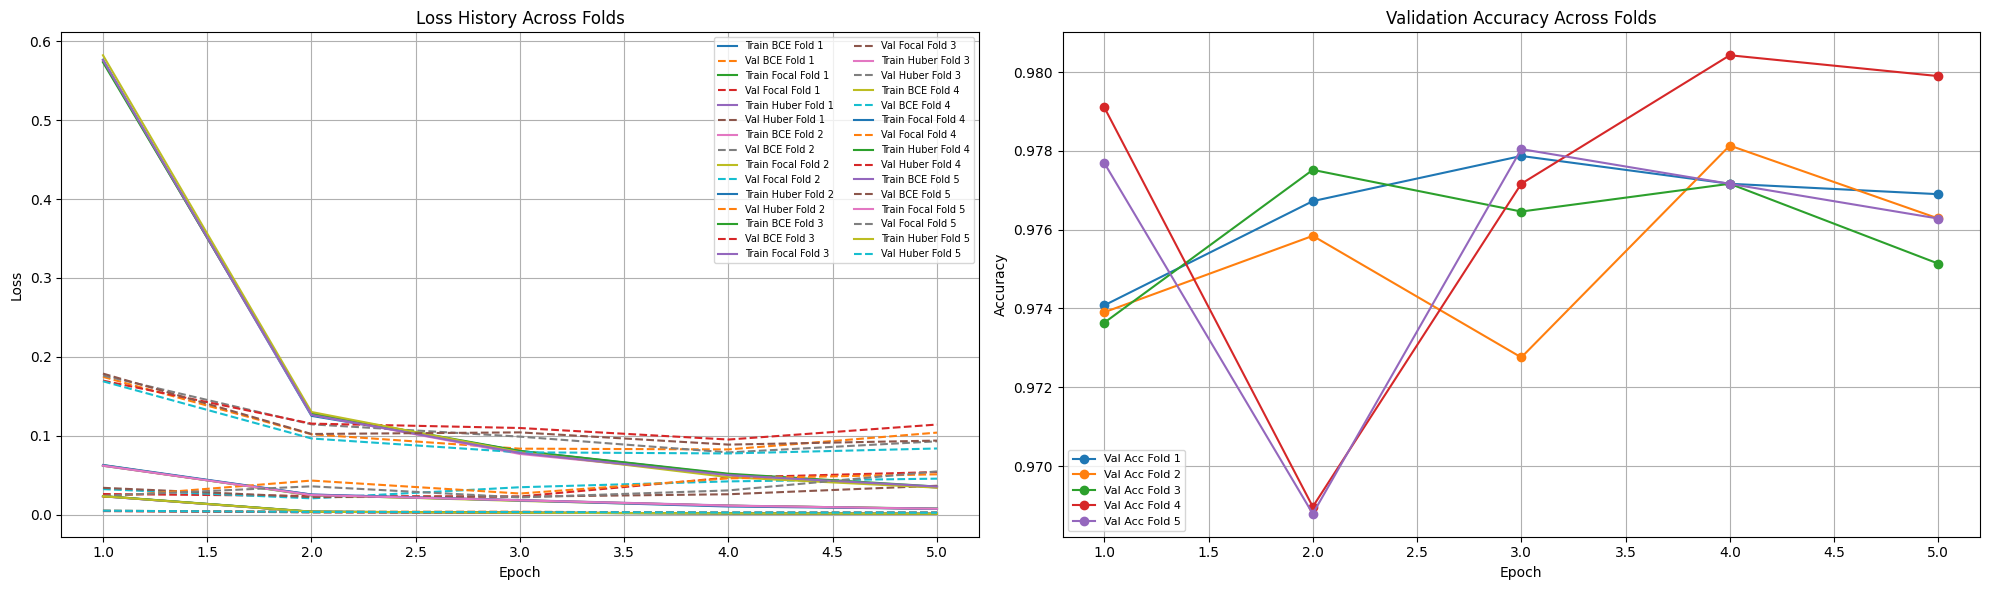

In [48]:
def plot_kfold_losses(train_loss_history, val_loss_history, val_accuracy_history, epochs, k_folds):
    

    plt.figure(figsize=(20, 6))

    # LOSS PLOT
    plt.subplot(1, 2, 1)
    for fold in range(k_folds):
        plt.plot(range(1, epochs + 1), train_loss_history['bce'][fold], label=f'Train BCE Fold {fold+1}', linestyle='-')
        plt.plot(range(1, epochs + 1), val_loss_history['bce'][fold], label=f'Val BCE Fold {fold+1}', linestyle='--')

        plt.plot(range(1, epochs + 1), train_loss_history['focal'][fold], label=f'Train Focal Fold {fold+1}', linestyle='-')
        plt.plot(range(1, epochs + 1), val_loss_history['focal'][fold], label=f'Val Focal Fold {fold+1}', linestyle='--')

        plt.plot(range(1, epochs + 1), train_loss_history['huber'][fold], label=f'Train Huber Fold {fold+1}', linestyle='-')
        plt.plot(range(1, epochs + 1), val_loss_history['huber'][fold], label=f'Val Huber Fold {fold+1}', linestyle='--')

    plt.title("Loss History Across Folds")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(fontsize=7, loc='upper right', ncol=2)  # Tighter legend
    plt.grid(True)

    # ACCURACY PLOT
    plt.subplot(1, 2, 2)
    for fold in range(k_folds):
        plt.plot(range(1, epochs + 1), val_accuracy_history[fold], label=f'Val Acc Fold {fold+1}', marker='o')

    plt.title("Validation Accuracy Across Folds")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(fontsize=8)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_kfold_losses(train_loss_history, val_loss_history, val_accuracy_history, EPOCHS, k_folds=5)